In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

In [2]:
fmnist = tf.keras.datasets.fashion_mnist

In [3]:
(training_images, training_labels), (test_images, test_labels) = fmnist.load_data()

In [4]:
import matplotlib.pyplot as plt


In [5]:
index=3
np.set_printoptions(linewidth=320)

In [6]:
print(f'LABELS: {training_labels[index]}')
print(f'\nIMAGE PIXEL ARRAY: {training_images[index]}')

LABELS: 3

IMAGE PIXEL ARRAY: [[  0   0   0   0   0   0   0   0  33  96 175 156  64  14  54 137 204 194 102   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0  73 186 177 183 175 188 232 255 223 219 194 179 186 213 146   0   0   0   0   0   0   0]
 [  0   0   0   0   0  35 163 140 150 152 150 146 175 175 173 171 156 152 148 129 156 140   0   0   0   0   0   0]
 [  0   0   0   0   0 150 142 140 152 160 156 146 142 127 135 133 140 140 137 133 125 169  75   0   0   0   0   0]
 [  0   0   0   0   0  54 167 146 129 142 137 137 131 148 148 133 131 131 131 125 140 140   0   0   0   0   0   0]
 [  0   0   0   0   0   0 110 188 133 146 152 133 125 127 119 129 133 119 140 131 150  14   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 221 158 137 135 123 110 110 114 108 112 117 127 142  77   0   0   0   0   0   0   0]
 [  0   0   0   0   0   4   0  25 158 137 125 119 119 110 117 117 110 119 127 144   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 123 156 129 112 

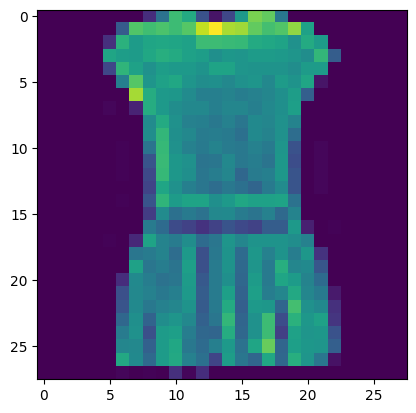

In [7]:
plt.imshow(training_images[index])
plt.show()

In [8]:
#normalize
training_images = training_images /255.0
test_images = test_images /255.0

In [9]:
model = tf.keras.Sequential([
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

In [10]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [11]:
model.fit(training_images, training_labels, epochs=100)

Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.8266 - loss: 0.4860
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8652 - loss: 0.3679
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8784 - loss: 0.3309
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8848 - loss: 0.3094
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8913 - loss: 0.2913
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8949 - loss: 0.2780
Epoch 7/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9013 - loss: 0.2641
Epoch 8/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9047 - loss: 0.2551
Epoch 9/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9080 - loss: 0.2439
Epoch 10/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9111 - loss: 0.2383
Epoch 11/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9130 - loss: 0.2272
Epoch 12/

In [12]:
model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8871 - loss: 0.8544


[0.8543826341629028, 0.8870999813079834]

In [13]:
classification = model.predict(test_images)
print(classification[3])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[0.0000000e+00 9.9999994e-01 0.0000000e+00 2.1735398e-27 0.0000000e+00 0.0000000e+00 1.0769658e-27 0.0000000e+00 0.0000000e+00 0.0000000e+00]


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (32, 784)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 128)              │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 64)               │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 10)               │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,160 (1.25 MB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 218,774 (854.59 KB)

In [15]:
from google.colab import files
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

In [20]:
class_names = ["T-Shirt","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneakers","Bag","Ankle Boot"]

Saving bag.jpg to bag (4).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


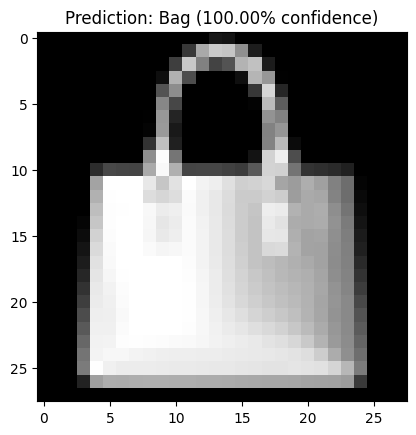

All class probabilities:
T-Shirt: 0.00%
Trouser: 0.00%
Pullover: 0.00%
Dress: 0.00%
Coat: 0.00%
Sandal: 0.00%
Shirt: 0.00%
Sneakers: 0.00%
Bag: 100.00%
Ankle Boot: 0.00%


In [48]:
uploaded = files.upload()
for file_name in uploaded.keys():
  img = Image.open(file_name).convert("L")
  img = ImageOps.invert(img)
  img = img.resize((28, 28))
  img_array = np.array(img)
  img_input = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_input)
predicted_index = np.argmax(prediction)
confidence = np.max(prediction[0]) * 100

plt.imshow(img_array, cmap=("gray"))
plt.title(f"Prediction: {class_names[predicted_index]} ({confidence:.2f}% confidence)")
plt.show()
print("All class probabilities:")
for name, prob in zip(class_names, prediction[0]):
 print(f"{name}: {prob*100:.2f}%")